In [1]:
import zipfile
import os
zip_ref = zipfile.ZipFile('C:/Users/swani/Downloads/chest-xrays.zip', 'r')
zip_ref.extractall('C:/Users/swani/OneDrive/Desktop/Deep_learning/project')
zip_ref.close()

In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Define the root directory and paths for the combined dataset
data_path = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray'
combined_path = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_total'

# Create a combined dataset directory
os.makedirs(combined_path, exist_ok=True)

# Combine all images from train, val, and test into a single directory for each class
for split in ['train', 'val', 'test']:
    for class_name in ['normal', 'pneumonia']:
        source_dir = os.path.join(data_path, split, class_name)
        target_dir = os.path.join(combined_path, class_name)
        os.makedirs(target_dir, exist_ok=True)
        for file_name in os.listdir(source_dir):
            source_file = os.path.join(source_dir, file_name)
            target_file = os.path.join(target_dir, file_name)
            shutil.copyfile(source_file, target_file)

In [4]:
# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(),  # Convert images to grayscale if not already
    transforms.RandomResizedCrop(size =256, scale= (0.8, 1.0) ),
    #transforms.Resize((224, 224)),  # Resize images to a fixed size
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(size =224),
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize the images
])

# Load the combined dataset
combined_dataset = datasets.ImageFolder(combined_path, transform=transform)

# Calculate split sizes
total_size = len(combined_dataset)
train_size = int(0.8 * total_size)
valid_size = int(0.1 * total_size)
test_size = total_size - train_size - valid_size

# Split the combined dataset
indices = list(range(total_size))
train_indices, temp_indices = train_test_split(indices, train_size=train_size, random_state=42)
valid_indices, test_indices = train_test_split(temp_indices, test_size=test_size, random_state=42)

# Create subset datasets
train_dataset = Subset(combined_dataset, train_indices)
val_dataset = Subset(combined_dataset, valid_indices)
test_dataset = Subset(combined_dataset, test_indices)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


In [5]:
import os
from torchvision.utils import save_image
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

# Define paths to save the datasets
train_dir = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_split/train'
val_dir = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_split/val'
test_dir = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_split/test'

# Map numeric labels to class names
label_to_class_name = {0: 'normal', 1: 'pneumonia'}

# Function to save a dataset to a folder
def save_dataset(dataset, output_dir, label_to_class_name):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    for i, (img, label) in enumerate(loader):
        class_name = label_to_class_name[label.item()]
        label_dir = os.path.join(output_dir, class_name)
        if not os.path.exists(label_dir):
            os.makedirs(label_dir)
        save_image(img[0], os.path.join(label_dir, f'{i}.png'))

# Save the datasets
save_dataset(train_dataset, train_dir, label_to_class_name)
save_dataset(val_dataset, val_dir, label_to_class_name)
save_dataset(test_dataset, test_dir, label_to_class_name)

print(f'Train dataset saved to: {train_dir}')
print(f'Validation dataset saved to: {val_dir}')
print(f'Test dataset saved to: {test_dir}')


Train dataset saved to: C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_split/train
Validation dataset saved to: C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_split/val
Test dataset saved to: C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_split/test


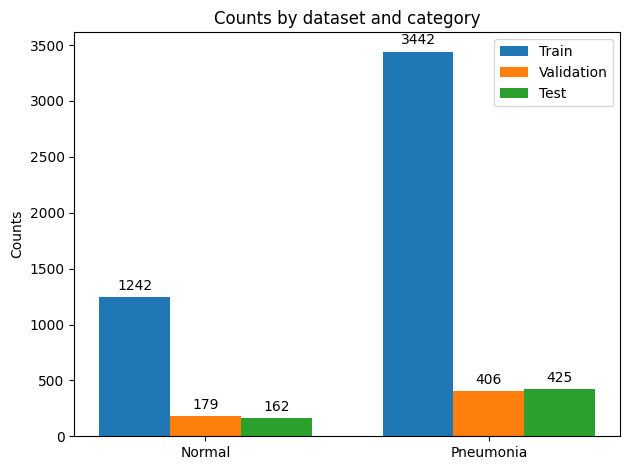

In [5]:
import matplotlib.pyplot as plt

def count_labels(dataloader):
    label_count = {'Normal': 0, 'Pneumonia': 0}
    for images, labels in dataloader:
        for label in labels:
            if label == 0:  # Assuming '0' is the label for 'Normal'
                label_count['Normal'] += 1
            else:  # Assuming '1' is the label for 'Pneumonia'
                label_count['Pneumonia'] += 1
    return label_count

# Assuming train_loader, valid_loader, and test_loader are already defined
train_counts = count_labels(train_loader)
valid_counts = count_labels(val_loader)
test_counts = count_labels(test_loader)

# Data to plot
labels = ['Normal', 'Pneumonia']
train_data = [train_counts['Normal'], train_counts['Pneumonia']]
valid_data = [valid_counts['Normal'], valid_counts['Pneumonia']]
test_data = [test_counts['Normal'], test_counts['Pneumonia']]

x = range(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x, train_data, width, label='Train')
rects2 = ax.bar([p + width for p in x], valid_data, width, label='Validation')
rects3 = ax.bar([p + width * 2 for p in x], test_data, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Counts')
ax.set_title('Counts by dataset and category')
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(labels)
ax.legend()

# Function to attach a text label above each bar
def autolabel(rects):
    """Attach a text label above each bar in rects, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

plt.show()

Train Set:


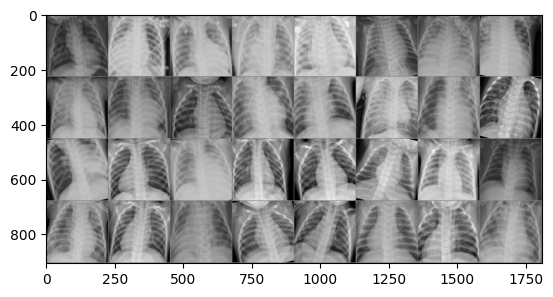

pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia normal normal pneumonia pneumonia pneumonia pneumonia normal pneumonia normal normal pneumonia pneumonia pneumonia
Validation Set:


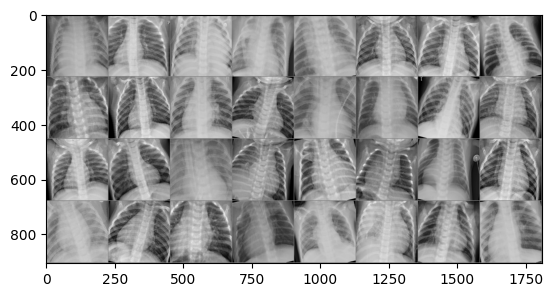

pneumonia normal pneumonia pneumonia pneumonia normal normal pneumonia pneumonia normal pneumonia normal pneumonia pneumonia pneumonia normal normal normal pneumonia pneumonia pneumonia normal pneumonia normal pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia
Test Set:


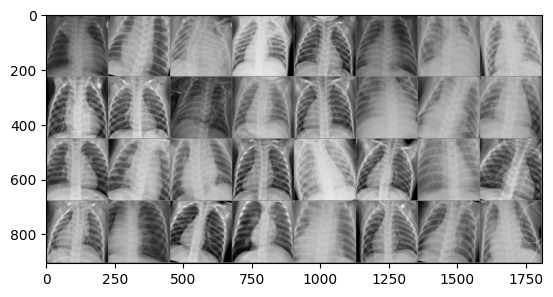

pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia normal pneumonia pneumonia normal pneumonia normal pneumonia pneumonia normal pneumonia pneumonia


In [6]:
import torchvision as torchvision
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils

# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Function to print and visualize data loader
def print_data_loader(data_loader, dataset_name):
    print(f'{dataset_name} Set:')
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    # Show images
    imshow(torchvision.utils.make_grid(images))
    # Print labels
    print(' '.join(f'{combined_dataset.classes[labels[j]]}' for j in range(len(labels))))

# Visualize the train loader
print_data_loader(train_loader, 'Train')

# Visualize the validation loader
print_data_loader(val_loader, 'Validation')

# Visualize the test loader
print_data_loader(test_loader, 'Test')


### BASE CNN

In [7]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class Base_CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(Base_CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256 * 28 * 28, 1024)  # Calculated based on pooling three times
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Conv + ReLU + Pool layers
        x = self.pool(F.relu(self.conv1(x)))  # 224x224 -> 112x112
        x = self.pool(F.relu(self.conv2(x)))  # 112x112 -> 56x56
        x = self.pool(F.relu(self.conv3(x)))  # 56x56 -> 28x28
        
        # Flatten the output for the fully connected layers
        x = x.view(-1, 256 * 28 * 28)
        
        # Fully connected layers with ReLU activation
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # Output layer
        x = self.fc3(x)
        
        return x

# Create the model instance and print its architecture
model = Base_CNN(num_classes=2) 
print(model)


Base_CNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=2, bias=True)
)


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pickle

# Check if GPU is available and set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Training on: {device}')

# Initialize the model, criterion, and optimizer
model = Base_CNN(2).to(device)  # Move the model to the GPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def train_val_model(model, train_loader, validation_loader, criterion, optimizer, epochs):
    best_val_loss = float('inf')
    best_model_state = None
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0.0
        total_train = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
            targets = targets.squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
                targets = targets.squeeze().long()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()

        avg_val_loss = val_loss / len(validation_loader.dataset)
        validation_accuracy = 100 * correct_val / total_val
        val_losses.append(avg_val_loss)
        val_accuracies.append(validation_accuracy)
        print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {validation_accuracy:.2f}%')

    return train_losses, val_losses, train_accuracies, val_accuracies

epochs = 10
train_losses, val_losses, train_accuracies, val_accuracies = train_val_model(model, train_loader, val_loader, criterion, optimizer, epochs=epochs)


Training on: cuda:0
Epoch 1/10, Loss: 0.4323, Training Accuracy: 80.25%
Validation Loss: 0.2861, Validation Accuracy: 88.21%
Epoch 2/10, Loss: 0.2585, Training Accuracy: 89.15%
Validation Loss: 0.2657, Validation Accuracy: 90.09%
Epoch 3/10, Loss: 0.2217, Training Accuracy: 91.50%
Validation Loss: 0.2256, Validation Accuracy: 90.09%
Epoch 4/10, Loss: 0.2127, Training Accuracy: 92.10%
Validation Loss: 0.1852, Validation Accuracy: 93.16%
Epoch 5/10, Loss: 0.1912, Training Accuracy: 92.66%
Validation Loss: 0.1833, Validation Accuracy: 92.99%
Epoch 6/10, Loss: 0.1958, Training Accuracy: 92.63%
Validation Loss: 0.2052, Validation Accuracy: 93.33%
Epoch 7/10, Loss: 0.1833, Training Accuracy: 92.81%
Validation Loss: 0.1833, Validation Accuracy: 94.36%
Epoch 8/10, Loss: 0.1718, Training Accuracy: 93.83%
Validation Loss: 0.1650, Validation Accuracy: 94.87%
Epoch 9/10, Loss: 0.1637, Training Accuracy: 94.02%
Validation Loss: 0.1714, Validation Accuracy: 93.68%
Epoch 10/10, Loss: 0.1673, Training

## CNN with dropout layers and early stopping

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class Adv_CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(Adv_CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout layers after each convolutional layer
        self.dropout_conv = nn.Dropout(0.5)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256 * 28 * 28, 1024)  # Calculated based on pooling three times
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
        
        # Dropout layers after fully connected layers
        self.dropout_fc = nn.Dropout(0.5)
        
    def forward(self, x):
        # Conv + ReLU + Pool + Dropout layers
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.dropout_conv(x)
        
        # Flatten the output for the fully connected layers
        x = x.view(-1, 256 * 28 * 28)
        
        # Fully connected layers with ReLU activation and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = F.relu(self.fc2(x))
        x = self.dropout_fc(x)
        
        # Output layer
        x = self.fc3(x)
        
        return x

# Create the model instance and print its architecture
model = Adv_CNN(num_classes=2) 
print(model)


Adv_CNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=200704, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=2, bias=True)
  (dropout_fc): Dropout(p=0.5, inplace=False)
)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pickle

# Check if GPU is available and set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Training on: {device}')

# Initialize the model, criterion, and optimizer
model = Adv_CNN(2).to(device)  # Move the model to the GPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def train_val_model(model, train_loader, validation_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    best_model_state = None
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    no_improvement_count = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0.0
        total_train = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
            targets = targets.squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
                targets = targets.squeeze().long()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()
                
        # Calculate validation accuracy and loss
        avg_val_loss = val_loss / len(validation_loader.dataset)
        val_accuracy = 100 * correct_val / total_val

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        if no_improvement_count >= patience:
            print(f'Early stopping at epoch {epoch+1} out of {epochs}')
            break
    
    # Save the best model
    if best_model_state is not None:
        torch.save(best_model_state, 'manishbi_hsriram_swanitha_project_checkpoint1.pkl')
        print(f'Saved best model with validation loss: {best_val_loss:.4f}')

    return train_losses, val_losses, train_accuracies, val_accuracies

epochs = 15
patience = 2  # Number of epochs with no improvement after which training will be stopped
train_losses, val_losses, train_accuracies, val_accuracies = train_val_model(model, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=patience)

# Load the best model
model.load_state_dict(torch.load('manishbi_hsriram_swanitha_project_checkpoint1.pkl'))


Training on: cuda:0
Epoch 1/15, Loss: 0.4881, Training Accuracy: 77.26%
Validation Loss: 0.4104, Validation Accuracy: 84.96%
Epoch 2/15, Loss: 0.3248, Training Accuracy: 86.29%
Validation Loss: 0.3051, Validation Accuracy: 90.77%
Epoch 3/15, Loss: 0.2943, Training Accuracy: 88.81%
Validation Loss: 0.3575, Validation Accuracy: 83.59%
Epoch 4/15, Loss: 0.2486, Training Accuracy: 90.33%
Validation Loss: 0.2848, Validation Accuracy: 88.38%
Epoch 5/15, Loss: 0.2379, Training Accuracy: 90.69%
Validation Loss: 0.3548, Validation Accuracy: 84.96%
Epoch 6/15, Loss: 0.2160, Training Accuracy: 91.52%
Validation Loss: 0.2217, Validation Accuracy: 92.65%
Epoch 7/15, Loss: 0.2172, Training Accuracy: 91.84%
Validation Loss: 0.2120, Validation Accuracy: 92.82%
Epoch 8/15, Loss: 0.2101, Training Accuracy: 91.99%
Validation Loss: 0.2177, Validation Accuracy: 92.48%
Epoch 9/15, Loss: 0.2059, Training Accuracy: 92.06%
Validation Loss: 0.2151, Validation Accuracy: 93.16%
Early stopping at epoch 9 out of 15

<All keys matched successfully>

In [12]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# Ensure device is set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Set the model in evaluation mode
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
predictions = []
true_labels = []
predicted_probs = []
test_accuracies_early = []
test_losses = []
best_test_accuracy = 0.0

# No gradient calculation needed during testing
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)  # Move inputs and labels to GPU
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        
        predictions.extend(predicted.cpu().numpy())  # Move predictions back to CPU for further processing
        true_labels.extend(labels.cpu().numpy())  # Move true labels back to CPU for further processing
        predicted_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())  # Store softmax probabilities

# Calculate test accuracy and loss
test_accuracy = 100 * correct_test / total_test
test_loss = test_loss / len(test_loader)

# Storing the test loss values for each batch into a list
test_losses.append(test_loss)
# Similarly storing accuracies into a list
test_accuracies_early.append(test_accuracy)

print(f'Test Accuracy: {test_accuracy:.2f}%')

if test_accuracy > best_test_accuracy:
    best_test_accuracy = test_accuracy

# Calculating the precision, recall, and F1 score
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

print(f'Test Accuracy: {best_test_accuracy:.2f}%')
print(f'Final Precision: {precision:.4f}')
print(f'Final Recall: {recall:.4f}')
print(f'Final F1 Score: {f1:.4f}')


Test Accuracy: 92.84%
Test Accuracy: 92.84%
Final Precision: 0.9284
Final Recall: 0.9284
Final F1 Score: 0.9284


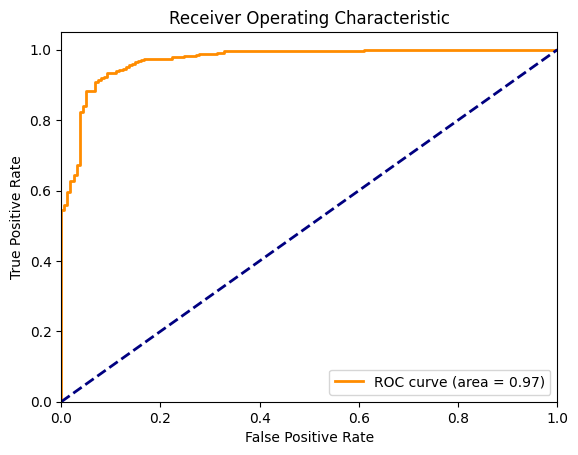

In [18]:
# Convert true_labels to binary format for ROC calculation
true_labels_binary = label_binarize(true_labels, classes=[0, 1])

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(true_labels_binary.ravel(), [prob[1] for prob in predicted_probs])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

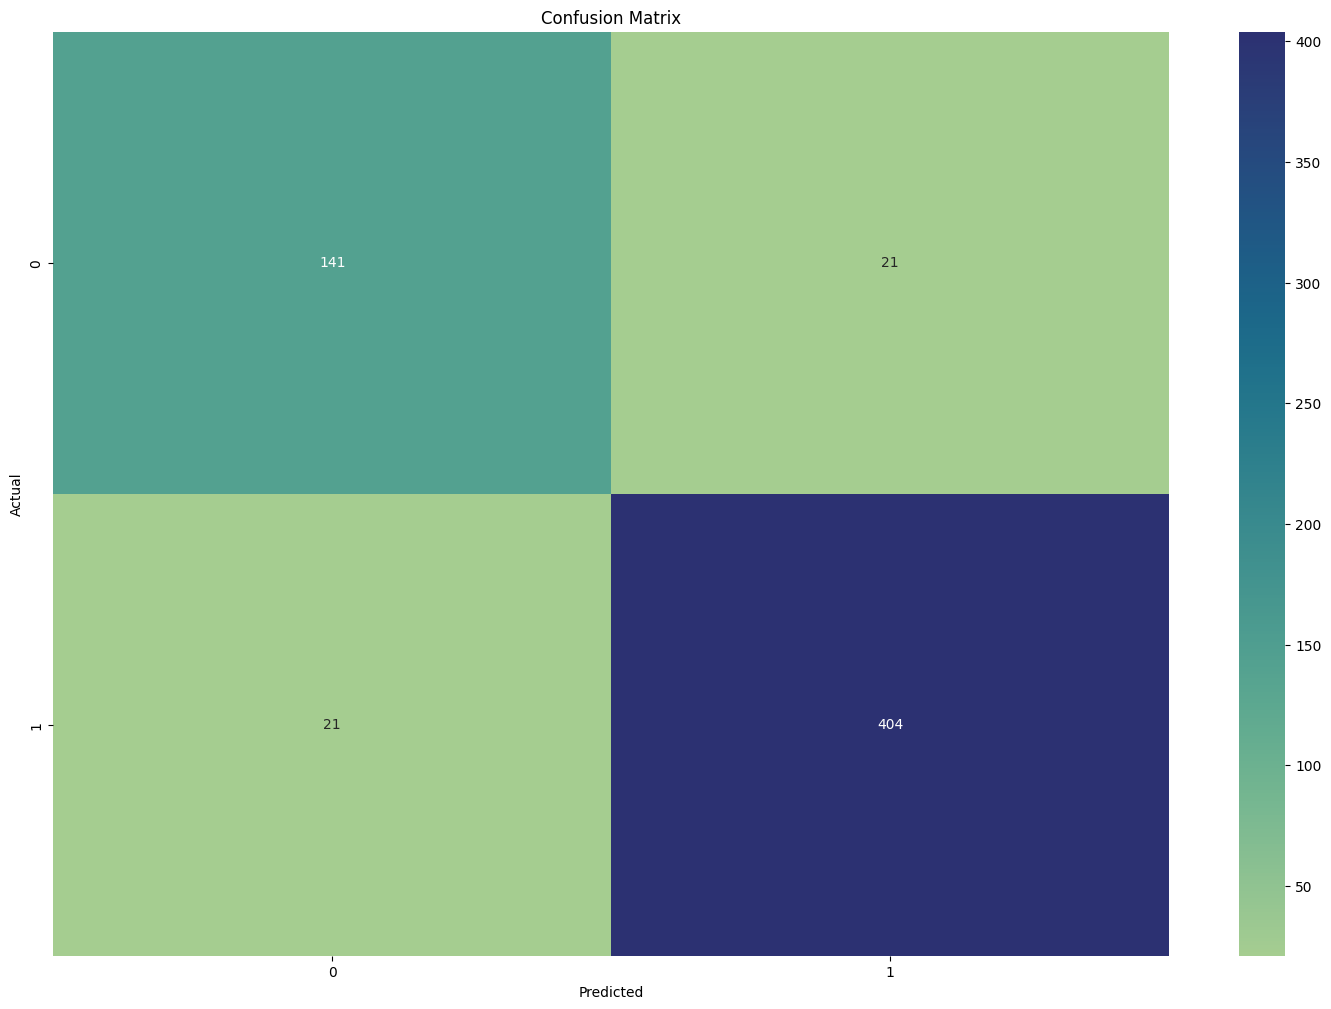

In [19]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion Matrix
confusion = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(18, 12))
sns.heatmap(confusion, annot=True, fmt='d', cmap='crest')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

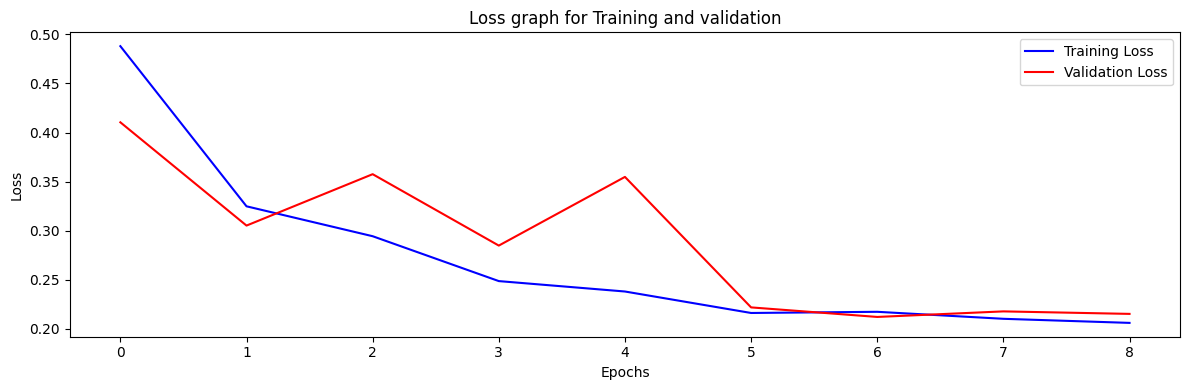

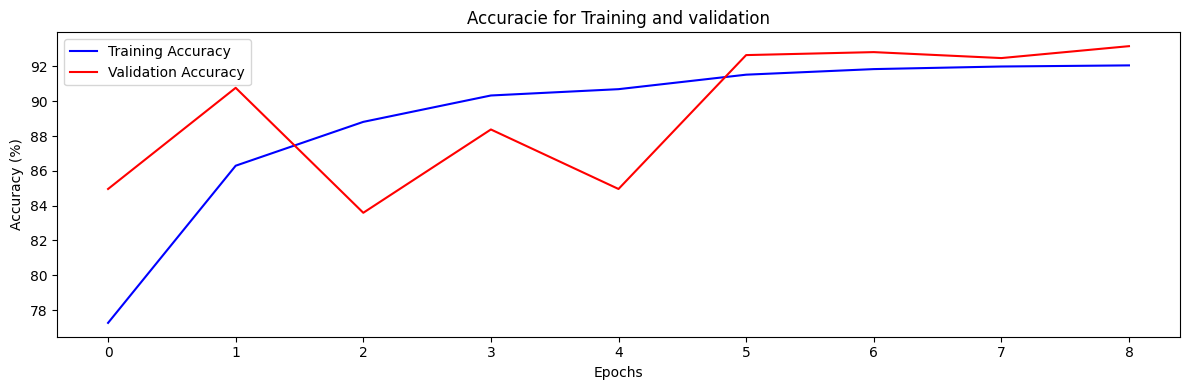

In [20]:
# Plot losses
plt.figure(figsize=(12, 4))

plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss graph for Training and validation')

plt.tight_layout()
plt.show()


#Plot accuracies
plt.figure(figsize=(12, 4))
plt.plot(train_accuracies, label='Training Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracie for Training and validation')

plt.tight_layout()
plt.show()